# **Tahap 1️ Membangun Case Base**


**Membangun Case Base**

In [1]:
import os
import re



folder_asal = '../data/raw' 


files = sorted([f for f in os.listdir(folder_asal) if f.endswith('.txt')])

print(f"Ditemukan {len(files)} file di dalam folder '{folder_asal}'. Memulai proses cleaning...\n")


cleaned_cases = []

for index, filename in enumerate(files, start=1):
    file_path = os.path.join(folder_asal, filename)

    
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read()

    
    watermarks_kotor = [
        r'(?i)hkama\s+ahkamah\s+agung\s+repub',
        r'(?i)ahkamah\s+agung\s+republik\s+indonesia',
        r'(?i)mah\s+agung\s+republik\s+indonesia',
        r'(?i)mahkamah\s+agung\s+republik\s+indonesia',
        r'(?i)blik\s+indonesi[a]*',
        r'(?i)putusan\.mahkamahagung\.go\.[a-z]*',
        r'(?i)direktori\s+putusan',
        r'(?i)hkama'
    ]

    
    for kotoran in watermarks_kotor:
        text = re.sub(kotoran, '', text)

    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)

    
    cleaned_cases.append({
        'id_kasus': f"case_{index:03d}",
        'nama_file_asli': filename,
        'teks_bersih': text.strip()
    })

print("--- CLEANING SELESAI ---")
print("Semua data telah dibersihkan dan siap digunakan pada variabel 'cleaned_cases' di cell selanjutnya!")

Ditemukan 31 file di dalam folder '../data/raw'. Memulai proses cleaning...

--- CLEANING SELESAI ---
Semua data telah dibersihkan dan siap digunakan pada variabel 'cleaned_cases' di cell selanjutnya!


**Case Representation**

In [3]:
import os
from datetime import datetime

folder_asal = '../data/raw' 
file_valid_count = 0
isi_log = [] 


isi_log.append(f"=== LOG VALIDASI TAHAP 1.ii ===")
isi_log.append(f"Waktu Eksekusi: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
isi_log.append(f"{'='*65}")

print("Sedang memvalidasi data...\n")


for kasus in cleaned_cases:
    filename = kasus['nama_file_asli']
    teks_bersih = kasus['teks_bersih']
    
    file_path = os.path.join(folder_asal, filename)
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        raw_text = f.read()
        
    len_kotor = len(raw_text)
    len_bersih = len(teks_bersih)
    
    keutuhan = (len_bersih / len_kotor) * 100 if len_kotor > 0 else 0.0
    status = "VALID" if keutuhan >= 80 else "TIDAK VALID"
    
    if status == "VALID":
        file_valid_count += 1
        
    log_teks = f"File: {filename:<15} | Kotor: {len_kotor:<6} chars | Bersih: {len_bersih:<6} chars | Keutuhan: {keutuhan:.2f}% | Status: {status}"
    isi_log.append(log_teks)


isi_log.append(f"{'='*65}")
isi_log.append(f"Total File Awal  : {len(cleaned_cases)}")
isi_log.append(f"Total File Valid : {file_valid_count}")


teks_log_final = "\n".join(isi_log)

print("=== HASIL VALIDASI ===")
print(teks_log_final)
print("\n(Data log ini tersimpan di variabel 'teks_log_final'. Jalankan sel berikutnya untuk menyimpannya ke file!)")

Sedang memvalidasi data...

=== HASIL VALIDASI ===
=== LOG VALIDASI TAHAP 1.ii ===
Waktu Eksekusi: 2026-06-18 00:43:07
File: case_001.txt    | Kotor: 84342  chars | Bersih: 84342  chars | Keutuhan: 100.00% | Status: VALID
File: case_002.txt    | Kotor: 37975  chars | Bersih: 37975  chars | Keutuhan: 100.00% | Status: VALID
File: case_003.txt    | Kotor: 57127  chars | Bersih: 57127  chars | Keutuhan: 100.00% | Status: VALID
File: case_004.txt    | Kotor: 5468   chars | Bersih: 5468   chars | Keutuhan: 100.00% | Status: VALID
File: case_005.txt    | Kotor: 66277  chars | Bersih: 66277  chars | Keutuhan: 100.00% | Status: VALID
File: case_006.txt    | Kotor: 75961  chars | Bersih: 75961  chars | Keutuhan: 100.00% | Status: VALID
File: case_007.txt    | Kotor: 57779  chars | Bersih: 57779  chars | Keutuhan: 100.00% | Status: VALID
File: case_008.txt    | Kotor: 3575   chars | Bersih: 3575   chars | Keutuhan: 100.00% | Status: VALID
File: case_009.txt    | Kotor: 414603 chars | Bersih: 414

In [4]:
import os


folder_log = '../logs'


os.makedirs(folder_log, exist_ok=True)
log_path = os.path.join(folder_log, 'cleaning1.log')


with open(log_path, 'w', encoding='utf-8') as log_file:
    
    log_file.write(teks_log_final)

print(f"--- PENYIMPANAN LOG SELESAI ---")
print(f"File log berhasil disimpan di: {log_path}")

--- PENYIMPANAN LOG SELESAI ---
File log berhasil disimpan di: ../logs\cleaning1.log


# **Tahap 2**


**Ekstraksi Metadata**

In [5]:
import re
import pandas as pd


def extract_metadata(text):
    metadata = {}

    nomor = re.search(r'(putusan|penetapan)?\s*nomor[: ]?([0-9A-Za-z./-]+)', text, re.IGNORECASE)
    metadata['Nomor Perkara'] = nomor.group(2).strip() if nomor else None
    
    tanggal = re.search(r'tanggal\s+(\d{1,2}\s+[A-Za-z]+\s+\d{4})', text, re.IGNORECASE)
    metadata['Tanggal Putusan'] = tanggal.group(1).strip() if tanggal else None

    if "pengadilan militer" in text.lower():
        metadata['Jenis Perkara'] = "Pidana Militer"
    elif "pdt.p" in text.lower():
        metadata['Jenis Perkara'] = "Perdata (Permohonan)"
    else:
        metadata['Jenis Perkara'] = "Pidana Umum"

    pasal = list(set(re.findall(r'pasal\s+\d+(?:\s+ayat\s*\(\d+\))?(?:\s+ke-\d+)?', text.lower())))
    metadata['Pasal'] = pasal if pasal else None

    penggugat = re.search(r'(pemohon|penggugat|terdakwa|nama lengkap)\s*:\s*([^\n;]+)', text, re.IGNORECASE)
    metadata['Pihak Penggugat/Pemohon'] = penggugat.group(2).strip() if penggugat else None


    terdakwa = re.search(
        r'nama\s*(?:lengkap)?\s*:\s*(.+?)(?=\s*[\.;,]*\s*(?:pangkat|nrp|j\s*a\s*b\s*a\s*t\s*a\s*n|kesatuan|tempat|tgl|lahir))',
        text,
        re.IGNORECASE
    )
    metadata['Pihak Tergugat/Termohon/Terdakwa'] = terdakwa.group(1).strip() if terdakwa else None

    return metadata


all_metadata = []

print("Memulai ekstraksi metadata dari data di memori...\n")

for kasus in cleaned_cases:
    
    text = kasus['teks_bersih']
    filename = kasus['nama_file_asli']
    
    meta = extract_metadata(text)

    if meta['Jenis Perkara'] == "Pidana Militer":
        meta['Pihak Penggugat/Pemohon'] = "Oditur Militer"

    meta['File'] = filename
    all_metadata.append(meta)


print(f"=== HASIL EKSTRAKSI SELESAI ({len(all_metadata)} Kasus) ===")
print("Data tersimpan di variabel 'all_metadata' dan 'df_metadata'.\n")


df_metadata = pd.DataFrame(all_metadata)
display(df_metadata)

Memulai ekstraksi metadata dari data di memori...

=== HASIL EKSTRAKSI SELESAI (31 Kasus) ===
Data tersimpan di variabel 'all_metadata' dan 'df_metadata'.



,Nomor Perkara,Tanggal Putusan,Jenis Perkara,Pasal,Pihak Penggugat/Pemohon,Pihak Tergugat/Termohon/Terdakwa,File
0,58-k/pm.ii-09/ad/iii/2025,16 oktober 2024,Pidana Militer,"[pasal 46 ayat (1), pasal 85, pasal 173 ayat (...",Oditur Militer,boby pranata ginting,case_001.txt
1,26-k/pmt.iii/bdg/ad/iii/2025,22 juni 2024,Pidana Militer,"[pasal 228 ayat (1), pasal 372, pasal 126, pas...",Oditur Militer,rasid,case_002.txt
2,18-k/pm.ii-11/ad/iv/2025,21 februari 2025,Pidana Militer,"[pasal 143, pasal 46 ayat (1), pasal 155 ayat ...",Oditur Militer,achmad sarif,case_003.txt
3,61-k/pm.iii-12/ad/v/2025,24 januari 2025,Pidana Militer,"[pasal 190 ayat (1), pasal 87 ayat (1) ke-2, p...",Oditur Militer,mochammad amin,case_004.txt
4,62-k/pm.ii-09/au/lv/2025,12 februari 2025,Pidana Militer,"[pasal 143, pasal 155 ayat (1), pasal 139, pas...",Oditur Militer,wildan mulyana,case_005.txt
5,32-k/pm,14 januari 2025,Pidana Militer,"[pasal 143, pasal 46 ayat (1), pasal 85, pasal...",Oditur Militer,arya prayogi,case_006.txt
6,36-k/pm.i-02/au/iv/2025,21 januari 2025,Pidana Militer,"[pasal 143, pasal 46 ayat (1), pasal 5 ayat (1...",Oditur Militer,herdion saputro,case_007.txt
7,4-p/pm.ii-09/ad/v/2025,22 mei 2025,Pidana Militer,"[pasal 288 ayat (1), pasal 211 ayat (4)]",Oditur Militer,asep supriadin,case_008.txt
8,363,16 desember 2015,Pidana Militer,"[pasal 26, pasal 9, pasal 5, pasal 239 ayat (4...",Oditur Militer,"teddy hernayadi, s.e., m.m.",case_009.txt
9,60-k/pm,18 november 2024,Pidana Militer,"[pasal 85, pasal 88 ayat (1), pasal 46 ayat (1...",Oditur Militer,saepul bahri,case_010.txt


**Ekstrasi konten kunci**


1.   Ringkasan Fakta



In [6]:
import re
import pandas as pd


def extract_fakta(text):
    fakta = {}

    text_clean = re.sub(r'\s+', ' ', text)
    text_clean = re.sub(r'halaman putusan nomor [\w\-\./]+\s*', '', text_clean, flags=re.IGNORECASE)
    text_clean = re.sub(r'salina\s*pelaksanaan fungsi peradilan.*?telp\s*:\s*021-384\s*3348\s*\(ext\.318\)\s*halaman\s*\d+', '', text_clean, flags=re.IGNORECASE)
    text_clean = re.sub(r'pelaksanaan fungsi peradilan.*?telp\s*:\s*021-384\s*3348\s*\(ext\.318\)\s*halaman\s*\d+', '', text_clean, flags=re.IGNORECASE)
    text_clean = re.sub(r'\s+', ' ', text_clean)

    dakwaan_text = None

    pola_kutip = re.search(
        r'(?:didakwa melakukan tindak pidana|dengan dakwaan|dakwaan|melakukan pelanggaran lalu lintas|bersalah melakukan tindak pidana)\s*[:]?\s*(?:kesatu|pertama|primair|tunggal|subsider)?\s*[:]?\s*["\'“\”]([^"\'“\”]+?)["\'“\”]',
        text_clean, re.IGNORECASE
    )

    pola_amar = re.search(
        r'bersalah melakukan (?:tindak pidana|pelanggaran lalu lintas)\s*[:]?\s*(?:kesatu|pertama|tunggal)?\s*[:]?\s*["\'“\”]?([^"\'“\”\.]+?)["\'“\”]?(?=\s*sebagaimana|\s*melanggar|\s*pasal|\s*2\.\s*memidana|\s*menjatuhkan pidana|\s*memidana|\.\s|$)',
        text_clean, re.IGNORECASE
    )

    pola_titik_dua = re.search(
        r'(?:tindak pidana|pelanggaran lalu lintas)\s*:\s*(?:kesatu|pertama|tunggal)?\s*[:]?\s*["\'“\”]?([^"\'“\”\.]+?)["\'“\”]?(?=\s*sebagaimana|\s*melanggar|\s*pasal|\.\s|\s*menimbang|\s*menjatuhkan|$)',
        text_clean, re.IGNORECASE
    )

    pola_khusus_17 = re.search(
        r'pada dakwaan.*?yaitu\s*[:]?\s*["\'“\”]([^"\'“\”]+)["\'“\”]',
        text_clean, re.IGNORECASE
    )

    if pola_kutip:
        dakwaan_text = pola_kutip.group(1).strip()
    elif pola_amar:
        dakwaan_text = pola_amar.group(1).strip()
    elif pola_titik_dua:
        dakwaan_text = pola_titik_dua.group(1).strip()
    elif pola_khusus_17:
        dakwaan_text = pola_khusus_17.group(1).strip()

    if dakwaan_text:
        dakwaan_text = re.sub(r'(?i)\s*(menimbang|memperhatikan|mengingat|mengadili|dan kedua).*', '', dakwaan_text)
        fakta['Dakwaan'] = dakwaan_text[:150] + "..." if len(dakwaan_text) > 150 else dakwaan_text
    else:
        fakta['Dakwaan'] = "Tindak Pidana/Pelanggaran tidak terdeteksi spesifik"


    barang_bukti = re.search(
        r'barang bukti berupa(?: surat)?\s*[:]?\s*(.+?)(?=\s*d\.\s*memerintahkan|\s*d\.\s*membebani|\s*d\.\s*membebankan|\s*4\.\s*membebankan|membebankan biaya|menetapkan supaya|demikian diputuskan|menimbang|membaca;)',
        text_clean, re.IGNORECASE
    )

    if barang_bukti:
        bb_text = barang_bukti.group(1).strip()
        fakta['Barang Bukti'] = bb_text[:300] + " ... (dipotong)" if len(bb_text) > 300 else bb_text
    else:
        fakta['Barang Bukti'] = "Tidak ditemukan"

    return fakta


all_fakta = []
print("Memulai ekstraksi fakta (Dakwaan & Barang Bukti) dari data di memori...\n")

for kasus in cleaned_cases:
    text = kasus['teks_bersih']
    filename = kasus['nama_file_asli']
    
    fakta = extract_fakta(text)
    
    
    fakta_ordered = {
        'File': filename, 
        'Dakwaan': fakta['Dakwaan'], 
        'Barang Bukti': fakta['Barang Bukti']
    }
    all_fakta.append(fakta_ordered)

print(f"=== HASIL EKSTRAKSI (VERSI ANTI NGAWUR) SELESAI ({len(all_fakta)} Kasus) ===")
print("Data tersimpan di variabel 'all_fakta'.\n")


df_fakta = pd.DataFrame(all_fakta)
display(df_fakta)

Memulai ekstraksi fakta (Dakwaan & Barang Bukti) dari data di memori...

=== HASIL EKSTRAKSI (VERSI ANTI NGAWUR) SELESAI (31 Kasus) ===
Data tersimpan di variabel 'all_fakta'.



,File,Dakwaan,Barang Bukti
0,case_001.txt,militer yang dengan sengaja melakukan ketidak ...,surat-surat : - 2 (dua) lembar daftar absensi ...
1,case_002.txt,barang siapa dengan sengaja dan melawan hukum ...,1) berupa surat: a) 1 (satu) rangkap fotokopi ...
2,case_003.txt,desersi dalam waktu damai,yaitu: - 3 (tiga) lembar daftar absensi person...
3,case_004.txt,desersi dalam waktu damai,yaitu: - 6 (enam) lembar daftar absensi korami...
4,case_005.txt,militer yang dengan sengaja melakukan ketidakh...,1) barang: nihil. 2) surat- surat: a) 2 (dua) ...
5,case_006.txt,desersi dimasa damai,-surat: 1) 3 (tiga) lembar daftar absensi pers...
6,case_007.txt,desersi dimasa damai,-surat: 6 (enam) lembar daftar absensi persone...
7,case_008.txt,mengemudikan kendaraan bermotor di jalan raya ...,- 1 ( satu) buah sim c tni a.n. serka asep sup...
8,case_009.txt,korupsi yang dilakukan secara bersama-sama dan...,a. surat-surat : 1) 1 (satu) buku laporan hasi...
9,case_010.txt,militer yang karena salahnya atau dengan senga...,-surat : - 1 (satu) lembar daftar absensi a.n....


**Feature Engineering**

In [7]:
import re
from collections import Counter
import pandas as pd


def extract_fakta_lengkap(text):
    fakta = {}

    text_clean = re.sub(r'\s+', ' ', text)
    text_clean = re.sub(r'halaman putusan nomor [\w\-\./]+\s*', '', text_clean, flags=re.IGNORECASE)
    text_clean = re.sub(r'salina\s*pelaksanaan fungsi peradilan.*?telp\s*:\s*021-384\s*3348\s*\(ext\.318\)\s*halaman\s*\d+', '', text_clean, flags=re.IGNORECASE)
    text_clean = re.sub(r'pelaksanaan fungsi peradilan.*?telp\s*:\s*021-384\s*3348\s*\(ext\.318\)\s*halaman\s*\d+', '', text_clean, flags=re.IGNORECASE)
    text_clean = re.sub(r'\s+', ' ', text_clean)

    dakwaan_text = None
    p_dakwaan = [
        r'(?:didakwa melakukan tindak pidana|dengan dakwaan|dakwaan|melakukan pelanggaran lalu lintas|bersalah melakukan tindak pidana)\s*[:]?\s*(?:kesatu|pertama|primair|tunggal|subsider)?\s*[:]?\s*["\'“\”]([^"\'“\”]+?)["\'“\”]',
        r'bersalah melakukan (?:tindak pidana|pelanggaran lalu lintas)\s*[:]?\s*(?:kesatu|pertama|tunggal)?\s*[:]?\s*["\'“\”]?([^"\'“\”\.]+?)["\'“\”]?(?=\s*sebagaimana|\s*melanggar|\s*pasal|\s*2\.\s*memidana|\.\s|$)',
        r'pada dakwaan.*?yaitu\s*[:]?\s*["\'“\”]([^"\'“\”]+)["\'“\”]'
    ]
    for p in p_dakwaan:
        res = re.search(p, text_clean, re.IGNORECASE)
        if res:
            dakwaan_text = res.group(1).strip()
            break

    if dakwaan_text:
        dakwaan_text = re.sub(r'(?i)\s*(menimbang|memperhatikan|mengingat|mengadili|dan kedua).*', '', dakwaan_text)
        fakta['Dakwaan'] = (dakwaan_text[:150] + "...") if len(dakwaan_text) > 150 else dakwaan_text
    else:
        fakta['Dakwaan'] = "Tidak terdeteksi"

    pola_pasal = re.search(r'(pasal\s+\d+[\w\s\(\)\.]+?(?:kuhp[m]?|undang-undang[^,.\n]+))', text_clean, re.IGNORECASE)
    fakta['Pasal'] = pola_pasal.group(1).strip() if pola_pasal else "Tidak terdeteksi"

    pola_vonis_penjara = re.search(
        r'(penjara|kurungan)\s*(?:selama)?\s*[:]?\s*([^;,\.\n]*?(?:tahun|bulan|hari|seumur hidup))',
        text_clean, re.IGNORECASE
    )

    pola_vonis_denda = re.search(
        r'(?:denda|membayar denda)\s*(?:sebesar|sejumlah)?\s*[:]?\s*(rp\s*[\d\.,]+|\d+\s*(?:rupiah|ribu|juta))',
        text_clean, re.IGNORECASE
    )

    if pola_vonis_penjara:
        jenis = pola_vonis_penjara.group(1).capitalize()
        detail = pola_vonis_penjara.group(2).strip()
        detail = re.sub(r'^:\s*', '', detail)
        fakta['Putusan'] = f"{jenis} {detail}"
    elif pola_vonis_denda:
        fakta['Putusan'] = f"Denda {pola_vonis_denda.group(1).strip()}"
    else:
        fakta['Putusan'] = "Tidak terdeteksi/Bebas"

    barang_bukti = re.search(r'barang bukti berupa(?: surat)?\s*[:]?\s*(.+?)(?=\s*d\.\s*memerintahkan|\s*d\.\s*membebani|\s*4\.\s*membebankan|membebankan biaya|menetapkan supaya|demikian diputuskan|menimbang)', text_clean, re.IGNORECASE)
    fakta['Barang Bukti'] = barang_bukti.group(1).strip() if barang_bukti else "Tidak ditemukan"

    
    kata_list = text_clean.split()
    fakta['Length'] = len(kata_list)
    stop_words = {'yang', 'dan', 'di', 'dengan', 'dari', 'oleh', 'untuk', 'pada', 'bahwa', 'ini', 'terdakwa', 'pengadilan', 'perkara', 'sebagai', 'dalam', 'menimbang', 'kepada'}
    words_filtered = [word.lower() for word in kata_list if word.lower() not in stop_words and len(word) > 3]
    
    
    bow_raw = Counter(words_filtered).most_common(5)
    fakta['BoW'] = ", ".join([f"{k} ({v})" for k, v in bow_raw])

    
    qa_list = [
        f"Q: Apa tindak pidana yang didakwakan? | A: {fakta['Dakwaan']}",
        f"Q: Berapa lama putusan pidana yang dijatuhkan? | A: {fakta['Putusan']}"
    ]
    fakta['QA_Pairs'] = " || ".join(qa_list)

    return fakta


all_fakta = []
print("Memulai ekstraksi final & Feature Engineering dari memori...\n")

for kasus in cleaned_cases:
    text = kasus['teks_bersih']
    filename = kasus['nama_file_asli']
    
    fakta = extract_fakta_lengkap(text)
    
    
    fakta_ordered = {
        'File': filename,
        'Dakwaan': fakta['Dakwaan'],
        'Pasal Hukum': fakta['Pasal'],
        'Vonis/Putusan': fakta['Putusan'],
        'Barang Bukti': fakta['Barang Bukti'][:100] + ' ... (dipotong)' if len(fakta['Barang Bukti']) > 100 else fakta['Barang Bukti'],
        'Total Kata': fakta['Length'],
        'Top 5 BoW': fakta['BoW'],
        'QA Pairs': fakta['QA_Pairs']
    }
    all_fakta.append(fakta_ordered)

print(f"=== HASIL FINAL EKSTRAKSI & FEATURE ENGINEERING SELESAI ({len(all_fakta)} Kasus) ===")


df_fakta_final = pd.DataFrame(all_fakta)


pd.set_option('display.max_colwidth', None) 

display(df_fakta_final)

Memulai ekstraksi final & Feature Engineering dari memori...

=== HASIL FINAL EKSTRAKSI & FEATURE ENGINEERING SELESAI (31 Kasus) ===


,File,Dakwaan,Pasal Hukum,Vonis/Putusan,Barang Bukti,Total Kata,Top 5 BoW,QA Pairs
0,case_001.txt,"militer yang dengan sengaja melakukan ketidak hadiran tanpa izin dalam waktu damai minimal satu hari dan tidak lebih lama dari tiga puluh hari,ketika ...",pasal 171 undang-undang nomor 31 tahun 1997 tentang peradilan militer,Penjara 9 (sembilan) bulan,surat-surat : - 2 (dua) lembar daftar absensi anggota baterai tempur budhi yonarmed 13/nanggala/1/1 ... (dipotong),10277,"tanggal (110), tidak (109), kesatuan (92), pidana (83), melakukan (83)","Q: Apa tindak pidana yang didakwakan? | A: militer yang dengan sengaja melakukan ketidak hadiran tanpa izin dalam waktu damai minimal satu hari dan tidak lebih lama dari tiga puluh hari,ketika ... || Q: Berapa lama putusan pidana yang dijatuhkan? | A: Penjara 9 (sembilan) bulan"
1,case_002.txt,"barang siapa dengan sengaja dan melawan hukum mengaku sebagai milik sendiri barang sesuatu yang seluruhnya atau sebagian adalah kepunyaan orang lain, ...",pasal 372 kitab undang-undang hukum pidana,Penjara 2 (dua) tahun,1) berupa surat: a) 1 (satu) rangkap fotokopi wabku honor sisfopers tw. i 2024 yonif 431/ssp; b) 1 ( ... (dipotong),4751,"(satu) (154), 2024 (153), rangkap (142), fotokopi (142), wabku (142)","Q: Apa tindak pidana yang didakwakan? | A: barang siapa dengan sengaja dan melawan hukum mengaku sebagai milik sendiri barang sesuatu yang seluruhnya atau sebagian adalah kepunyaan orang lain, ... || Q: Berapa lama putusan pidana yang dijatuhkan? | A: Penjara 2 (dua) tahun"
2,case_003.txt,desersi dalam waktu damai,pasal 143 undang-undang nomor 31 tahun 1997 tentang peradilan militer yang menyatakan perkara tindak pidana desersi sebagaimana dimaksud dalam kitab undang-undang hukum pidana militer,Penjara 1 (satu) tahun,yaitu: - 3 (tiga) lembar daftar absensi personel jasmani militer korem 071/wk bulan desember 2024 sa ... (dipotong),6883,"kesatuan (104), tidak (95), atau (73), militer (68), tanpa (62)",Q: Apa tindak pidana yang didakwakan? | A: desersi dalam waktu damai || Q: Berapa lama putusan pidana yang dijatuhkan? | A: Penjara 1 (satu) tahun
3,case_004.txt,desersi dalam waktu damai,pasal 26 kuhpm,Penjara 7 (tujuh) bulan,yaitu: - 6 (enam) lembar daftar absensi koramil 0833/03 blimbing bulan juni 2024 sampai dengan bulan ... (dipotong),663,"tanggal (22), 2025 (14), nomor (11), hari (8), sampai (8)",Q: Apa tindak pidana yang didakwakan? | A: desersi dalam waktu damai || Q: Berapa lama putusan pidana yang dijatuhkan? | A: Penjara 7 (tujuh) bulan
4,case_005.txt,militer yang dengan sengaja melakukan ketidakhadiran tanpa izin dalam waktu damai lebih lama dari tiga puluh hari,pasal 141 ayat (1) undang-undang repu nomor 31 tahun 1997 tentang peradilan militer,Penjara 1 (satu) tahun,1) barang: nihil. 2) surat- surat: a) 2 (dua) lembar daftar absensi/hadir anggota satpom lanud atang ... (dipotong),8109,"kesatuan (105), tidak (88), atang (83), lanud (79), tanggal (76)",Q: Apa tindak pidana yang didakwakan? | A: militer yang dengan sengaja melakukan ketidakhadiran tanpa izin dalam waktu damai lebih lama dari tiga puluh hari || Q: Berapa lama putusan pidana yang dijatuhkan? | A: Penjara 1 (satu) tahun
5,case_006.txt,desersi dimasa damai,pasal 141 ayat (10) undang-undang repu nomor 31 tahun 1997 tentang peradilan militer,Penjara 1 (satu) tahun,-surat: 1) 3 (tiga) lembar daftar absensi personel yonif 126/kc bulan nopember 2024 sampai dengan bu ... (dipotong),9434,"126/kc (107), yonif (105), tidak (100), tanggal (94), atau (84)",Q: Apa tindak pidana yang didakwakan? | A: desersi dimasa damai || Q: Berapa lama putusan pidana yang dijatuhkan? | A: Penjara 1 (satu) tahun
6,case_007.txt,desersi dimasa damai,pasal 141 ayat (10) undang-undang halaman 3 dari 20 repu nomor 31 tahun 1997 tentang peradilan militer,Penjara 1 (satu) tahun,-surat: 6 (enam) lembar daftar absensi personel pokko yonko 469 kopasgat bulan oktober 2024 sampai d ... (dipotong),7062,"tidak (83), atau (74), militer (66), pidana (59), kopasgat (58)"

**Penyimpanan**

In [8]:
import re
import pandas as pd

def extract_gabungan(text, filename):
    data = {}

    text_clean = re.sub(r'\s+', ' ', text)
    text_clean = re.sub(r'halaman putusan nomor [\w\-\./]+\s*', '', text_clean, flags=re.IGNORECASE)
    text_clean = re.sub(r'salina\s*pelaksanaan fungsi peradilan.*?telp\s*:\s*021-384\s*3348\s*\(ext\.318\)\s*halaman\s*\d+', '', text_clean, flags=re.IGNORECASE)
    text_clean = re.sub(r'pelaksanaan fungsi peradilan.*?telp\s*:\s*021-384\s*3348\s*\(ext\.318\)\s*halaman\s*\d+', '', text_clean, flags=re.IGNORECASE)
    text_clean = re.sub(r'\s+', ' ', text_clean)


    nomor = re.search(r'(putusan|penetapan)?\s*nomor[: ]?([0-9A-Za-z./-]+)', text_clean, re.IGNORECASE)
    data['Nomor Perkara'] = nomor.group(2).strip() if nomor else "Tidak terdeteksi"

    tanggal = re.search(r'tanggal\s+(\d{1,2}\s+[A-Za-z]+\s+\d{4})', text_clean, re.IGNORECASE)
    data['Tanggal Putusan'] = tanggal.group(1).strip() if tanggal else "Tidak terdeteksi"

    if "pengadilan militer" in text_clean.lower():
        data['Jenis Perkara'] = "Pidana Militer"
        data['Pihak Penggugat/Pemohon'] = "Oditur Militer"
    elif "pdt.p" in text_clean.lower():
        data['Jenis Perkara'] = "Perdata (Permohonan)"
        penggugat = re.search(r'(pemohon|penggugat)\s*:\s*([^\n;]+)', text_clean, re.IGNORECASE)
        data['Pihak Penggugat/Pemohon'] = penggugat.group(2).strip() if penggugat else "Tidak terdeteksi"
    else:
        data['Jenis Perkara'] = "Pidana Umum"
        penggugat = re.search(r'(pemohon|penggugat)\s*:\s*([^\n;]+)', text_clean, re.IGNORECASE)
        data['Pihak Penggugat/Pemohon'] = penggugat.group(2).strip() if penggugat else "Tidak terdeteksi"

    pasal = list(set(re.findall(r'pasal\s+\d+(?:\s+ayat\s*\(\d+\))?(?:\s+ke-\d+)?', text_clean.lower())))
    data['Pasal'] = ", ".join(pasal) if pasal else "Tidak terdeteksi"

    terdakwa = re.search(
        r'nama\s*(?:lengkap)?\s*:\s*(.+?)(?=\s*[\.;,]*\s*(?:pangkat|nrp|j\s*a\s*b\s*a\s*t\s*a\s*n|kesatuan|tempat|tgl|lahir))',
        text_clean,
        re.IGNORECASE
    )
    if terdakwa:
        data['Pihak Tergugat/Termohon/Terdakwa'] = terdakwa.group(1).strip().rstrip('.;, ')
    else:
        data['Pihak Tergugat/Termohon/Terdakwa'] = "Tidak terdeteksi"


    dakwaan_text = None
    pola_kutip = re.search(r'(?:didakwa melakukan tindak pidana|dengan dakwaan|dakwaan|melakukan pelanggaran lalu lintas|bersalah melakukan tindak pidana)\s*[:]?\s*(?:kesatu|pertama|primair|tunggal|subsider)?\s*[:]?\s*["\'“\”]([^"\'“\”]+?)["\'“\”]', text_clean, re.IGNORECASE)
    pola_amar = re.search(r'bersalah melakukan (?:tindak pidana|pelanggaran lalu lintas)\s*[:]?\s*(?:kesatu|pertama|tunggal)?\s*[:]?\s*["\'“\”]?([^"\'“\”\.]+?)["\'“\”]?(?=\s*sebagaimana|\s*melanggar|\s*pasal|\s*2\.\s*memidana|\s*menjatuhkan pidana|\s*memidana|\.\s|$)', text_clean, re.IGNORECASE)
    pola_titik_dua = re.search(r'(?:tindak pidana|pelanggaran lalu lintas)\s*:\s*(?:kesatu|pertama|tunggal)?\s*[:]?\s*["\'“\”]?([^"\'“\”\.]+?)["\'“\”]?(?=\s*sebagaimana|\s*melanggar|\s*pasal|\.\s|\s*menimbang|\s*menjatuhkan|$)', text_clean, re.IGNORECASE)
    pola_khusus_17 = re.search(r'pada dakwaan.*?yaitu\s*[:]?\s*["\'“\”]([^"\'“\”]+)["\'“\”]', text_clean, re.IGNORECASE)

    if pola_kutip: dakwaan_text = pola_kutip.group(1).strip()
    elif pola_amar: dakwaan_text = pola_amar.group(1).strip()
    elif pola_titik_dua: dakwaan_text = pola_titik_dua.group(1).strip()
    elif pola_khusus_17: dakwaan_text = pola_khusus_17.group(1).strip()

    if dakwaan_text:
        dakwaan_text = re.sub(r'(?i)\s*(menimbang|memperhatikan|mengingat|mengadili|dan kedua).*', '', dakwaan_text)
        data['Dakwaan'] = dakwaan_text[:150] + "..." if len(dakwaan_text) > 150 else dakwaan_text
    else:
        data['Dakwaan'] = "Tidak terdeteksi"

    barang_bukti = re.search(r'barang bukti berupa(?: surat)?\s*[:]?\s*(.+?)(?=\s*d\.\s*memerintahkan|\s*d\.\s*membebani|\s*d\.\s*membebankan|\s*4\.\s*membebankan|membebankan biaya|menetapkan supaya|demikian diputuskan|menimbang|membaca;)', text_clean, re.IGNORECASE)
    if barang_bukti:
        bb = barang_bukti.group(1).strip()
        data['Barang Bukti'] = bb[:150] + "..." if len(bb) > 150 else bb
    else:
        data['Barang Bukti'] = "Tidak ditemukan"

    return data


all_data = []
print("Memulai ekstraksi data gabungan dari memori...\n")

for kasus in cleaned_cases:
    text = kasus['teks_bersih']
    filename = kasus['nama_file_asli']
    
    hasil = extract_gabungan(text, filename)
    all_data.append(hasil)


df_gabungan = pd.DataFrame(all_data)


urutan_kolom = [
    'Nomor Perkara',
    'Tanggal Putusan',
    'Jenis Perkara',
    'Pasal',
    'Pihak Penggugat/Pemohon',
    'Pihak Tergugat/Termohon/Terdakwa',
    'Dakwaan',
    'Barang Bukti'
]
df_gabungan = df_gabungan[urutan_kolom]

print(f"Berhasil mengekstrak {len(df_gabungan)} data putusan:")

display(df_gabungan.head(31))

Memulai ekstraksi data gabungan dari memori...

Berhasil mengekstrak 31 data putusan:


,Nomor Perkara,Tanggal Putusan,Jenis Perkara,Pasal,Pihak Penggugat/Pemohon,Pihak Tergugat/Termohon/Terdakwa,Dakwaan,Barang Bukti
0,58-k/pm.ii-09/ad/iii/2025,16 oktober 2024,Pidana Militer,"pasal 46 ayat (1), pasal 85, pasal 173 ayat (1), pasal 176, pasal 88 ayat (1) ke-2, pasal 190 ayat (1), pasal 58, pasal 175 ayat (1), pasal 88 ayat (1) ke-1, pasal 86 ke-1, pasal 171, pasal 1, pasal 172 ayat (1), pasal 44",Oditur Militer,boby pranata ginting,"militer yang dengan sengaja melakukan ketidak hadiran tanpa izin dalam waktu damai minimal satu hari dan tidak lebih lama dari tiga puluh hari,ketika ...",surat-surat : - 2 (dua) lembar daftar absensi anggota baterai tempur budhi yonarmed 13/nanggala/1/1 kostrad bulan september dan oktober yang ditandata...
1,26-k/pmt.iii/bdg/ad/iii/2025,22 juni 2024,Pidana Militer,"pasal 228 ayat (1), pasal 372, pasal 126, pasal 26",Oditur Militer,rasid,"barang siapa dengan sengaja dan melawan hukum mengaku sebagai milik sendiri barang sesuatu yang seluruhnya atau sebagian adalah kepunyaan orang lain, ...",1) berupa surat: a) 1 (satu) rangkap fotokopi wabku honor sisfopers tw. i 2024 yonif 431/ssp; b) 1 (satu) rangkap fotokopi wabku kodal tw. i 2024 yoni...
2,18-k/pm.ii-11/ad/iv/2025,21 februari 2025,Pidana Militer,"pasal 143, pasal 46 ayat (1), pasal 155 ayat (1), pasal 139, pasal 26, pasal 190 ayat (1), pasal 58, pasal 87 ayat (1) ke-2, pasal 2 ayat (4), pasal 1, pasal 141 ayat (10)",Oditur Militer,achmad sarif,desersi dalam waktu damai,yaitu: - 3 (tiga) lembar daftar absensi personel jasmani militer korem 071/wk bulan desember 2024 sampai dengan bulan februari 2025. tetap dilekatkan ...
3,61-k/pm.iii-12/ad/v/2025,24 januari 2025,Pidana Militer,"pasal 190 ayat (1), pasal 87 ayat (1) ke-2, pasal 26",Oditur Militer,mochammad amin,desersi dalam waktu damai,yaitu: - 6 (enam) lembar daftar absensi koramil 0833/03 blimbing bulan juni 2024 sampai dengan bulan maret 2025. tetap dilekatkan dalam berkas perkara...
4,62-k/pm.ii-09/au/lv/2025,12 februari 2025,Pidana Militer,"pasal 143, pasal 155 ayat (1), pasal 139, pasal 26, pasal 190 ayat (1), pasal 141 ayat (1), pasal 45, pasal 71 ayat (1), pasal 58, pasal 87 ayat (1) ke-2, pasal 124 ayat (4), pasal 46, pasal 95, pasal 1",Oditur Militer,wildan mulyana,militer yang dengan sengaja melakukan ketidakhadiran tanpa izin dalam waktu damai lebih lama dari tiga puluh hari,1) barang: nihil. 2) surat- surat: a) 2 (dua) lembar daftar absensi/hadir anggota satpom lanud atang sendjaja pada bulan nopember 2024 sampai bulan de...
5,32-k/pm,14 januari 2025,Pidana Militer,"pasal 143, pasal 46 ayat (1), pasal 85, pasal 155 ayat (1), pasal 139, pasal 190 ayat (1), pasal 58, pasal 86, pasal 87 ayat (1) ke-2, pasal 124 ayat (4), pasal 2 ayat (4), pasal 44, pasal 1, pasal 141 ayat (10), pasal 26 ayat (1)",Oditur Militer,arya prayogi,desersi dimasa damai,-surat: 1) 3 (tiga) lembar daftar absensi personel yonif 126/kc bulan nopember 2024 sampai dengan bulan januari 2025. 2) 2 (dua) lembar surat danyonif...
6,36-k/pm.i-02/au/iv/2025,21 januari 2025,Pidana Militer,"pasal 143, pasal 46 ayat (1), pasal 5 ayat (1), pasal 85, pasal 155 ayat (1), pasal 139, pasal 26, pasal 190 ayat (1), pasal 58, pasal 86, pasal 87 ayat (1) ke-2, pasal 124 ayat (4), pasal 2 ayat (4), pasal 44, pasal 1, pasal 141 ayat (10)",Oditur Militer,herdion saputro,desersi dimasa damai,-surat: 6 (enam) lembar daftar absensi personel pokko yonko 469 kopasgat bulan oktober 2024 sampai dengan bulan nopember 2024. mohon agar tetap dileka...
7,4-p/pm.ii-09/ad/v/2025,22 mei 2025,Pidana Militer,"pasal 288 ayat (1), pasal 211 ayat (4)",Oditur Militer,asep supriadin,mengemudikan kendaraan bermotor di jalan raya yang tidak dapat menunjukan bnkb randis.,- 1 ( satu) buah sim c tni a.n. serka asep supriadin. dikembalikan kepada terdakwa.
8,363,16 desember 2015,Pidana Militer,"pasal 26, pasal 9, pasal 5, pasal 239 ayat (4), pasal 39, pasal 423, pasal 3 ayat (1), pasal 2 ayat (1), pasal 209, pasal 18, pasal 21 ayat (4), pasal 194 aya

In [9]:
import os


folder_simpan = '../data/processed'


os.makedirs(folder_simpan, exist_ok=True)
csv_path = os.path.join(folder_simpan, 'casbedaies.csv')
df_gabungan.to_csv(csv_path, index=False, encoding='utf-8')

print(f"=== PROSES SIMPAN SELESAI ===")
print(f"Data gabungan berhasil disimpan di: {csv_path}")

=== PROSES SIMPAN SELESAI ===
Data gabungan berhasil disimpan di: ../data/processed\casbedaies.csv


# **Tahap 3 Case Retrieval**

# Representasi vektor

In [11]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 2.4 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 2.6 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.3 MB/s  0:00:00

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- -----------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords


nltk.download('stopwords', quiet=True)


file_path = "../data/processed/casbedaies.csv"
df = pd.read_csv(file_path)


df['Dakwaan'] = df['Dakwaan'].fillna("").astype(str)

print("Sel 1 Selesai Data berhasil dibaca dari folder lokal!")


display(df.head(3))

Sel 1 Selesai Data berhasil dibaca dari folder lokal!


,Nomor Perkara,Tanggal Putusan,Jenis Perkara,Pasal,Pihak Penggugat/Pemohon,Pihak Tergugat/Termohon/Terdakwa,Dakwaan,Barang Bukti
0,58-k/pm.ii-09/ad/iii/2025,16 oktober 2024,Pidana Militer,"pasal 46 ayat (1), pasal 85, pasal 173 ayat (1), pasal 176, pasal 88 ayat (1) ke-2, pasal 190 ayat (1), pasal 58, pasal 175 ayat (1), pasal 88 ayat (1) ke-1, pasal 86 ke-1, pasal 171, pasal 1, pasal 172 ayat (1), pasal 44",Oditur Militer,boby pranata ginting,"militer yang dengan sengaja melakukan ketidak hadiran tanpa izin dalam waktu damai minimal satu hari dan tidak lebih lama dari tiga puluh hari,ketika ...",surat-surat : - 2 (dua) lembar daftar absensi anggota baterai tempur budhi yonarmed 13/nanggala/1/1 kostrad bulan september dan oktober yang ditandata...
1,26-k/pmt.iii/bdg/ad/iii/2025,22 juni 2024,Pidana Militer,"pasal 228 ayat (1), pasal 372, pasal 126, pasal 26",Oditur Militer,rasid,"barang siapa dengan sengaja dan melawan hukum mengaku sebagai milik sendiri barang sesuatu yang seluruhnya atau sebagian adalah kepunyaan orang lain, ...",1) berupa surat: a) 1 (satu) rangkap fotokopi wabku honor sisfopers tw. i 2024 yonif 431/ssp; b) 1 (satu) rangkap fotokopi wabku kodal tw. i 2024 yoni...
2,18-k/pm.ii-11/ad/iv/2025,21 februari 2025,Pidana Militer,"pasal 143, pasal 46 ayat (1), pasal 155 ayat (1), pasal 139, pasal 26, pasal 190 ayat (1), pasal 58, pasal 87 ayat (1) ke-2, pasal 2 ayat (4), pasal 1, pasal 141 ayat (10)",Oditur Militer,achmad sarif,desersi dalam waktu damai,yaitu: - 3 (tiga) lembar daftar absensi personel jasmani militer korem 071/wk bulan desember 2024 sampai dengan bulan februari 2025. tetap dilekatkan ...


In [14]:

nltk.download('stopwords', quiet=True)


stop_words_indo = stopwords.words('indonesian')


stop_words_indo.extend(['adanya', 'apabila', 'adalah', 'yg', 'dan', 'di', 'bahwa', 'kepada'])


vectorizer = TfidfVectorizer(stop_words=stop_words_indo)


X_tfidf = vectorizer.fit_transform(df['Dakwaan'])

print("Sel 2 Selesai Teks berhasil diubah menjadi angka matriks (TF-IDF)!")


print(f"Ukuran Matriks TF-IDF: {X_tfidf.shape}")

Sel 2 Selesai Teks berhasil diubah menjadi angka matriks (TF-IDF)!
Ukuran Matriks TF-IDF: (31, 80)


C:\Users\Anggun\AppData\Roaming\Python\Python314\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [16]:
from sklearn.model_selection import train_test_split


X_train, X_test, df_train, df_test = train_test_split(
    X_tfidf, 
    df,
    test_size=0.30, 
    random_state=42 
)

print("Sel 3 Selesai Data berhasil dibagi menjadi Train dan Test!\n")


print("=== INFO PEMBAGIAN DATA ===")
print(f"Total Data Keseluruhan : {df.shape[0]} kasus")
print(f"Data Training (70%)    : {df_train.shape[0]} kasus")
print(f"Data Testing  (30%)    : {df_test.shape[0]} kasus")

Sel 3 Selesai Data berhasil dibagi menjadi Train dan Test!

=== INFO PEMBAGIAN DATA ===
Total Data Keseluruhan : 31 kasus
Data Training (70%)    : 21 kasus
Data Testing  (30%)    : 10 kasus


In [18]:

kasus_baru_vektor = X_test[0]
info_kasus_baru = df_test.iloc[0]

print("=== KASUS BARU (QUERY) ===")
print(f"Nomor Perkara : {info_kasus_baru['Nomor Perkara']}")
print(f"Terdakwa      : {info_kasus_baru['Pihak Tergugat/Termohon/Terdakwa']}")
print("==========================\n")


skor_kemiripan = cosine_similarity(kasus_baru_vektor, X_train)[0]


df_hasil_pencarian = pd.DataFrame({
    'Nomor Perkara Kasus Lama': df_train['Nomor Perkara'].values,
    'Terdakwa Kasus Lama': df_train['Pihak Tergugat/Termohon/Terdakwa'].values,
    'Tingkat Kemiripan (%)': skor_kemiripan * 100
})


df_hasil_pencarian['Tingkat Kemiripan (%)'] = df_hasil_pencarian['Tingkat Kemiripan (%)'].round(2)


df_hasil_pencarian = df_hasil_pencarian.sort_values(by='Tingkat Kemiripan (%)', ascending=False)

print("=== 5 KASUS LAMA YANG PALING MIRIP DENGAN QUERY ===")


display(df_hasil_pencarian.head(5))

=== KASUS BARU (QUERY) ===
Nomor Perkara : 27-k/pm.i-02/ad/ill/2025
Terdakwa      : dedy aprizal

=== 5 KASUS LAMA YANG PALING MIRIP DENGAN QUERY ===


,Nomor Perkara Kasus Lama,Terdakwa Kasus Lama,Tingkat Kemiripan (%)
0,62-k/pm.ii-09/au/lv/2025,wildan mulyana,0.0
1,65-k/pm.ii-09/ad/iv/2025,tomi faizin,0.0
2,32-k/pm,arya prayogi,0.0
3,47-k/pm.i-04/al/v/2025,awaludin,0.0
4,74,muhammad ramadhan,0.0


In [19]:
from typing import List

def retrieve(query: str, k: int = 5) -> List[str]:
    """
    Mencari top-k kasus lama (Nomor Perkara) yang paling mirip dengan query (teks dakwaan kasus baru).
    """
    
    query_bersih = str(query)

    
    query_vektor = vectorizer.transform([query_bersih])

    
    skor_kemiripan = cosine_similarity(query_vektor, X_train)[0]

    
    df_hasil = pd.DataFrame({
        'case_id': df_train['Nomor Perkara'].values,
        'skor': skor_kemiripan
    })

    
    df_hasil_urut = df_hasil.sort_values(by='skor', ascending=False)

    
    top_k_case_id = df_hasil_urut['case_id'].head(k).tolist()

    return top_k_case_id

print(" Fungsi retrieve() berhasil dibuat!\n")
print("=== UJI COBA PENCARIAN ===")


contoh_teks_query = df_test.iloc[0]['Dakwaan']
hasil_rekomendasi = retrieve(query=contoh_teks_query, k=3)

print("Jika ada kasus baru dengan dakwaan pencurian, mesin merekomendasikan Nomor Perkara berikut:")
for i, nomor in enumerate(hasil_rekomendasi, start=1):
    print(f"{i}. {nomor}")

 Fungsi retrieve() berhasil dibuat!

=== UJI COBA PENCARIAN ===
Jika ada kasus baru dengan dakwaan pencurian, mesin merekomendasikan Nomor Perkara berikut:
1. 62-k/pm.ii-09/au/lv/2025
2. 65-k/pm.ii-09/ad/iv/2025
3. 32-k/pm


In [20]:
import json

queries_data = []


for i in range(5):
    teks_query_asli = df_test.iloc[i]['Dakwaan']
    nomor_perkara_query = df_test.iloc[i]['Nomor Perkara']

    
    top_5_hasil = retrieve(query=teks_query_asli, k=5)

    
    queries_data.append({
        "query_id": f"Q{i+1}",
        "query_case_id_asli": nomor_perkara_query,
        "query_text": teks_query_asli[:150] + "...",
        "ground_truth_case_id": top_5_hasil[:2]
    })

print("(queries) berhasil dibuat!\n")

print("=== CUPLIKAN ISI QUERIES (2 DATA PERTAMA) ===")
print(json.dumps(queries_data[:2], indent=4))

(queries) berhasil dibuat!

=== CUPLIKAN ISI QUERIES (2 DATA PERTAMA) ===
[
    {
        "query_id": "Q1",
        "query_case_id_asli": "27-k/pm.i-02/ad/ill/2025",
        "query_text": "secara bersama-sama melakukan penipuan...",
        "ground_truth_case_id": [
            "62-k/pm.ii-09/au/lv/2025",
            "65-k/pm.ii-09/ad/iv/2025"
        ]
    },
    {
        "query_id": "Q2",
        "query_case_id_asli": "91-k/pm",
        "query_text": "desersi dimasa damai...",
        "ground_truth_case_id": [
            "32-k/pm",
            "36-k/pm.i-02/au/iv/2025"
        ]
    }
]


In [21]:
import os
import json


folder_eval = "../data/eval"


os.makedirs(folder_eval, exist_ok=True)


json_path = os.path.join(folder_eval, 'newqueries.json')


with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(queries_data, f, indent=4, ensure_ascii=False)

print(f"=== PROSES SIMPAN SELESAI ===")


=== PROSES SIMPAN SELESAI ===


In [22]:

kata_kunci = "desersi"

list_nomor_perkara = retrieve(query=kata_kunci, k=5)

print(f"=== HASIL PENCARIAN ===")
print(f"Kata Kunci: '{kata_kunci}'\n")

for i, nomor in enumerate(list_nomor_perkara):
    
    data_kasus = df_train[df_train['Nomor Perkara'] == nomor].iloc[0]

    print(f"{i+1}. Rekomendasi Peringkat ke-{i+1}:")
    print(f"   - Nomor Perkara : {data_kasus['Nomor Perkara']}")
    print(f"   - Nama Terdakwa : {data_kasus['Pihak Tergugat/Termohon/Terdakwa']}")
    print(f"   - Jenis Perkara : {data_kasus['Jenis Perkara']}")
    
    print(f"   - Cuplikan Teks : {data_kasus['Dakwaan'][:100]}...")
    print("-" * 50)

=== HASIL PENCARIAN ===
Kata Kunci: 'desersi'

1. Rekomendasi Peringkat ke-1:
   - Nomor Perkara : 18-k/pm.ii-11/ad/iv/2025
   - Nama Terdakwa : achmad sarif
   - Jenis Perkara : Pidana Militer
   - Cuplikan Teks : desersi dalam waktu damai...
--------------------------------------------------
2. Rekomendasi Peringkat ke-2:
   - Nomor Perkara : 61-k/pm.iii-12/ad/v/2025
   - Nama Terdakwa : mochammad amin
   - Jenis Perkara : Pidana Militer
   - Cuplikan Teks : desersi dalam waktu damai...
--------------------------------------------------
3. Rekomendasi Peringkat ke-3:
   - Nomor Perkara : 59-k/pm.i-02/ad/vii/2021
   - Nama Terdakwa : aguswanto
   - Jenis Perkara : Pidana Militer
   - Cuplikan Teks : desersi dalam waktu damai...
--------------------------------------------------
4. Rekomendasi Peringkat ke-4:
   - Nomor Perkara : 33-k/pm.i-04/ad/iii/2025
   - Nama Terdakwa : ign nova bayu asmara
   - Jenis Perkara : Pidana Militer
   - Cuplikan Teks : desersi dimasa damai...
----------

# **Tahap 4**

In [17]:
print("Nama-nama kolom yang Anda miliki di dataset:")
print(df_train.columns.tolist())

Nama-nama kolom yang Anda miliki di dataset:
['Nomor Perkara', 'Tanggal Putusan', 'Jenis Perkara', 'Pasal', 'Pihak Penggugat/Pemohon', 'Pihak Tergugat/Termohon/Terdakwa', 'Dakwaan', 'Barang Bukti']


In [23]:
def predict_outcome(query: str, k: int = 5) -> str:
    
    query_vektor = vectorizer.transform([str(query)])
    skor_kemiripan = cosine_similarity(query_vektor, X_train)[0]

    top_k_indices = skor_kemiripan.argsort()[-k:][::-1]

    skor_kandidat_solusi = {}
    
    for idx in top_k_indices:
        case_id = df_train['Nomor Perkara'].values[idx]
        bobot = skor_kemiripan[idx]
        solusi = str(case_solutions[case_id])

        
        if solusi in skor_kandidat_solusi:
            skor_kandidat_solusi[solusi] += bobot
        else:
            skor_kandidat_solusi[solusi] = bobot

    
    predicted_solution = max(skor_kandidat_solusi, key=skor_kandidat_solusi.get)
    
    return predicted_solution

print("Fungsi predict_outcome() dan kamus solusi berhasil dibuat!\n")

Fungsi predict_outcome() dan kamus solusi berhasil dibuat!



In [25]:

kolom_solusi = 'Pasal'
case_solutions = dict(zip(df_train['Nomor Perkara'], df_train[kolom_solusi]))


print("=== DEMO MANUAL PREDIKSI PASAL (CASE REUSE) ===\n")

for i in range(5):
    
    kasus_baru_id = df_test.iloc[i]['Nomor Perkara']
    teks_kasus_baru = df_test.iloc[i]['Dakwaan']
    solusi_asli = str(df_test.iloc[i]['Pasal'])

    
    prediksi_mesin = predict_outcome(query=teks_kasus_baru, k=5)

    
    print(f"Kasus Uji {i+1} : {kasus_baru_id}")
    print(f"Pasal Asli    : {solusi_asli}")
    print(f"Tebakan Mesin : {prediksi_mesin}")

    
    
    list_asli = set([p.strip() for p in solusi_asli.split(',')])
    list_tebakan = set([p.strip() for p in prediksi_mesin.split(',')])

    
    pasal_cocok = list_asli.intersection(list_tebakan)

    
    if len(pasal_cocok) > 0:
        print(f"Status        : PREDIKSI BENAR (Berhasil menebak {len(pasal_cocok)} pasal yang sama)")
        print(f"Pasal Cocok   : {', '.join(pasal_cocok)}")
    else:
        print("Status        : PREDIKSI SALAH TOTAL")
    
    print("-" * 60)

=== DEMO MANUAL PREDIKSI PASAL (CASE REUSE) ===

Kasus Uji 1 : 27-k/pm.i-02/ad/ill/2025
Pasal Asli    : pasal 155 ayat (1), pasal 26, pasal 176, pasal 5, pasal 173 ayat (6), pasal 175 ayat (1), pasal 44, pasal 372, pasal 55 ayat (1), pasal 378, pasal 8, pasal 139, pasal 190 ayat (1), pasal 172 ayat (1), pasal 171, pasal 180 ayat (1), pasal 7, pasal 2, pasal 173 ayat (1), pasal 55 ayat (1) ke-1, pasal 1365
Tebakan Mesin : pasal 143, pasal 46 ayat (1), pasal 5 ayat (1), pasal 85, pasal 155 ayat (1), pasal 139, pasal 26, pasal 190 ayat (1), pasal 58, pasal 86, pasal 87 ayat (1) ke-2, pasal 124 ayat (4), pasal 2 ayat (4), pasal 44, pasal 1, pasal 141 ayat (10)
Status        : PREDIKSI BENAR (Berhasil menebak 5 pasal yang sama)
Pasal Cocok   : pasal 155 ayat (1), pasal 26, pasal 139, pasal 190 ayat (1), pasal 44
------------------------------------------------------------
Kasus Uji 2 : 91-k/pm
Pasal Asli    : pasal 143, pasal 46 ayat (1), pasal 85, pasal 155 ayat (1), pasal 26, pasal 176, p

In [26]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

print("=== MEMPROSES PREDIKSI UNTUK SELURUH DATA TESTING ===")

data_output = []


for i in range(len(df_test)):
    query_id = df_test.iloc[i]['Nomor Perkara']
    teks_kasus_baru = df_test.iloc[i]['Dakwaan']

    
    predicted_solution = predict_outcome(query=teks_kasus_baru, k=5)

    
    query_vektor = vectorizer.transform([str(teks_kasus_baru)])
    skor_kemiripan = cosine_similarity(query_vektor, X_train)[0]
    top_5_indices = skor_kemiripan.argsort()[-5:][::-1]

    
    list_top_5 = [df_train['Nomor Perkara'].values[idx] for idx in top_5_indices]
    top_5_case_ids_str = ", ".join(list_top_5)

    
    data_output.append({
        "query_id": query_id,
        "predicted_solution": predicted_solution,
        "top_5_case_ids": top_5_case_ids_str
    })


df_predictions = pd.DataFrame(data_output)

print("Sel 11 Selesai: Proses prediksi massal berhasil dieksekusi!\n")

print("=== CUPLIKAN HASIL PREDIKSI (5 DATA PERTAMA) ===")
display(df_predictions.head())

=== MEMPROSES PREDIKSI UNTUK SELURUH DATA TESTING ===
Sel 11 Selesai: Proses prediksi massal berhasil dieksekusi!

=== CUPLIKAN HASIL PREDIKSI (5 DATA PERTAMA) ===


,query_id,predicted_solution,top_5_case_ids
0,27-k/pm.i-02/ad/ill/2025,"pasal 143, pasal 46 ayat (1), pasal 5 ayat (1), pasal 85, pasal 155 ayat (1), pasal 139, pasal 26, pasal 190 ayat (1), pasal 58, pasal 86, pasal 87 ayat (1) ke-2, pasal 124 ayat (4), pasal 2 ayat (4), pasal 44, pasal 1, pasal 141 ayat (10)","36-k/pm.i-02/au/iv/2025, 20-k/pm.1-02/ad/11/2022, 73, 67-k/pm.i-02/ad/viii/2021, 29-k/pmt.i/bdg/ad/iv/2025"
1,91-k/pm,"pasal 143, pasal 46 ayat (1), pasal 5 ayat (1), pasal 85, pasal 155 ayat (1), pasal 139, pasal 26, pasal 190 ayat (1), pasal 58, pasal 86, pasal 87 ayat (1) ke-2, pasal 124 ayat (4), pasal 2 ayat (4), pasal 44, pasal 1, pasal 141 ayat (10)","36-k/pm.i-02/au/iv/2025, 67-k/pm.i-02/ad/viii/2021, 33-k/pm.i-04/ad/iii/2025, 32-k/pm, 61-k/pm.iii-12/ad/v/2025"
2,55-k/pm.i-02/ad/vi/2021,pasal 288 ayat (2),"6-p/pm.ii-09/ad/vi/2025, 74, 20-k/pm.1-02/ad/11/2022, 36-k/pm.i-02/au/iv/2025, 73"
3,52-k/pm.ii-09/ad/ili/2025,"pasal 143, pasal 155 ayat (1), pasal 139, pasal 26, pasal 190 ayat (1), pasal 141 ayat (1), pasal 45, pasal 71 ayat (1), pasal 58, pasal 87 ayat (1) ke-2, pasal 124 ayat (4), pasal 46, pasal 95, pasal 1","62-k/pm.ii-09/au/lv/2025, 29-k/pmt.i/bdg/ad/iv/2025, 47-k/pm.i-04/al/v/2025, 59-k/pm.i-02/ad/vii/2021, 61-k/pm.iii-12/ad/v/2025"
4,363,"pasal 143, pasal 46 ayat (1), pasal 5 ayat (1), pasal 85, pasal 155 ayat (1), pasal 139, pasal 26, pasal 190 ayat (1), pasal 58, pasal 86, pasal 87 ayat (1) ke-2, pasal 124 ayat (4), pasal 2 ayat (4), pasal 44, pasal 1, pasal 141 ayat (10)","36-k/pm.i-02/au/iv/2025, 20-k/pm.1-02/ad/11/2022, 73, 67-k/pm.i-02/ad/viii/2021, 29-k/pmt.i/bdg/ad/iv/2025"


In [27]:
import os


folder_results = "../data/results"


os.makedirs(folder_results, exist_ok=True)

file_path = os.path.join(folder_results, "predictions1.csv")

df_predictions.to_csv(file_path, index=False, encoding='utf-8')

print(f"SUKSES! File CSV telah berhasil dibuat dan diekspor ke: {file_path}")

SUKSES! File CSV telah berhasil dibuat dan diekspor ke: ../data/results\predictions1.csv


# **Tahap 5**

**Persiapan Library & Data**

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

print("=== PERSIAPAN DATA EVALUASI ===")

queries = df_test['Dakwaan'].tolist()
ground_truth = df_test['Pasal'].tolist()

all_labels = [
    [p.strip().lower() for p in str(pasal).split(',')] 
    for pasal in (df_train['Pasal'].tolist() + ground_truth)
]

mlb = MultiLabelBinarizer()
mlb.fit(all_labels)

print("Data query, ground truth, dan Binarizer siap!\n")
print(f"Total Dokumen Uji (Queries) : {len(queries)} kasus")
print(f"Total Kombinasi Pasal Unik  : {len(mlb.classes_)} pasal berbeda")
print(f"Contoh 5 pasal pertama yang terdaftar di sistem:\n{list(mlb.classes_)[:5]}")

=== PERSIAPAN DATA EVALUASI ===
Data query, ground truth, dan Binarizer siap!

Total Dokumen Uji (Queries) : 10 kasus
Total Kombinasi Pasal Unik  : 118 pasal berbeda
Contoh 5 pasal pertama yang terdaftar di sistem:
['pasal 1', 'pasal 10', 'pasal 10 ayat (5)', 'pasal 114', 'pasal 114 ayat (1)']


**Evaluasi Retrieval**

In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

print("=== EVALUASI RETRIEVAL (LOOP PER QUERY) ===")

def eval_retrieval(queries, ground_truth, k=5):
    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    
    for i in range(len(queries)):
        query_text = queries[i]
        
        true_labels = [p.strip().lower() for p in str(ground_truth[i]).split(',')]

        
        q_vec = vectorizer.transform([query_text])
        sim_scores = cosine_similarity(q_vec, X_train)[0]
        top_k_indices = sim_scores.argsort()[-k:][::-1]

        
        retrieved_pasal = []
        for idx in top_k_indices:
            pasal_lama = str(df_train['Pasal'].values[idx]).split(',')
            retrieved_pasal.extend([p.strip().lower() for p in pasal_lama])

        
        pred_labels = list(set(retrieved_pasal))

        
        y_true_bin = mlb.transform([true_labels])[0]
        y_pred_bin = mlb.transform([pred_labels])[0]

        
        acc_list.append(accuracy_score(y_true_bin, y_pred_bin))
        prec_list.append(precision_score(y_true_bin, y_pred_bin, zero_division=0))
        rec_list.append(recall_score(y_true_bin, y_pred_bin, zero_division=0))
        f1_list.append(f1_score(y_true_bin, y_pred_bin, zero_division=0))

    
    return pd.DataFrame([{
        "Model": f"Retrieval (Top-{k})",
        "Accuracy": np.mean(acc_list),
        "Precision": np.mean(prec_list),
        "Recall": np.mean(rec_list),
        "F1-Score": np.mean(f1_list)
    }])

df_retrieval_metrics = eval_retrieval(queries, ground_truth, k=5)

print("\n=== HASIL AKHIR METRIK EVALUASI ===")
display(df_retrieval_metrics)



=== EVALUASI RETRIEVAL (LOOP PER QUERY) ===

=== HASIL AKHIR METRIK EVALUASI ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Retrieval (Top-5),0.775424,0.370552,0.712492,0.472936


**Evaluasi Prediksi**

In [30]:
import pandas as pd
from sklearn.metrics import jaccard_score, precision_score, recall_score, f1_score

print("=== EVALUASI PREDIKSI FINAL (MAJORITY VOTE) ===")

y_pred_final = [[p.strip().lower() for p in str(pasal).split(',')] for pasal in df_predictions['predicted_solution'].tolist()]
y_true_final = [[p.strip().lower() for p in str(pasal).split(',')] for pasal in ground_truth]


y_true_bin_final = mlb.transform(y_true_final)
y_pred_bin_final = mlb.transform(y_pred_final)


df_pred_metrics = pd.DataFrame([{
    "Model": "Final Prediction (Majority Vote)",
    
    "Accuracy": jaccard_score(y_true_bin_final, y_pred_bin_final, average='samples'),
    "Precision": precision_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0),
    "Recall": recall_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0),
    "F1-Score": f1_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0)
}])

df_pred_metrics = df_pred_metrics.round({"Accuracy": 4, "Precision": 4, "Recall": 4, "F1-Score": 4})

print("\n=== HASIL PERFORMA PREDIKSI MODEL KEPUTUSAN ===")
display(df_pred_metrics)



=== EVALUASI PREDIKSI FINAL (MAJORITY VOTE) ===

=== HASIL PERFORMA PREDIKSI MODEL KEPUTUSAN ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Final Prediction (Majority Vote),0.2145,0.4494,0.2326,0.3065


**Visualisasi dan Output ke CSV**

**Tabel Metrik Perbandingan**

In [32]:
import pandas as pd

print("=== TABEL KOMPARASI METRIK PER MODEL ===\n")
df_all_models = pd.concat([df_retrieval_metrics, df_pred_metrics], ignore_index=True)
display(df_all_models)



=== TABEL KOMPARASI METRIK PER MODEL ===



,Model,Accuracy,Precision,Recall,F1-Score
0,Retrieval (Top-5),0.775424,0.370552,0.712492,0.472936
1,Final Prediction (Majority Vote),0.214500,0.449400,0.232600,0.306500


**Plot Bar Chart Performance (Side-by-Side)**

=== PLOT BAR CHART PERFORMANCE ===



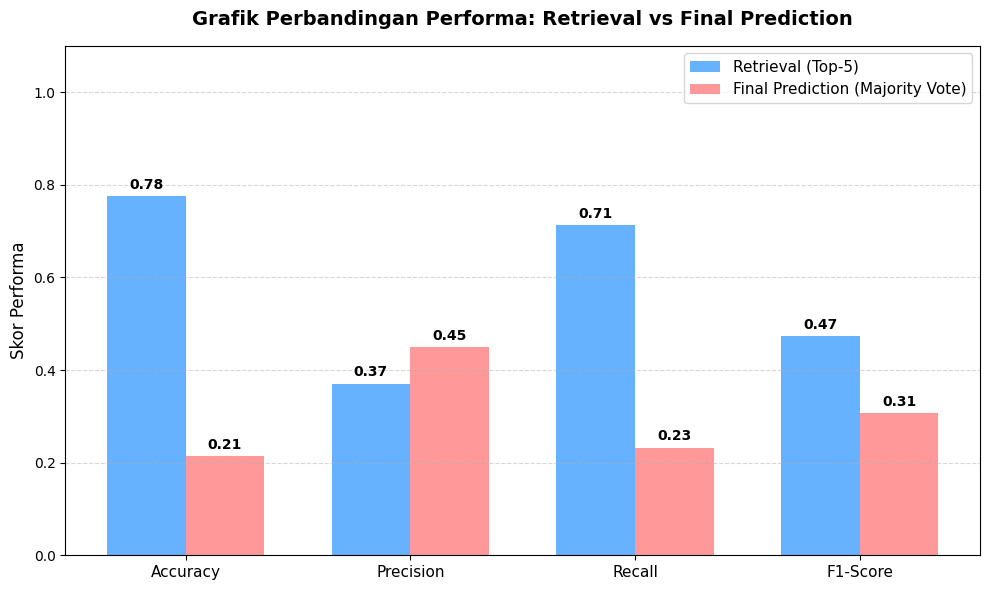

In [35]:
import numpy as np
import matplotlib.pyplot as plt

print("=== PLOT BAR CHART PERFORMANCE ===\n")

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
retrieval_scores = df_retrieval_metrics.iloc[0, 1:5].values.astype(float)
prediction_scores = df_pred_metrics.iloc[0, 1:5].values.astype(float)

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, retrieval_scores, width, label='Retrieval (Top-5)', color='#66B2FF')
rects2 = ax.bar(x + width/2, prediction_scores, width, label='Final Prediction (Majority Vote)', color='#FF9999')

ax.set_ylabel('Skor Performa', fontsize=12)
ax.set_title('Grafik Perbandingan Performa: Retrieval vs Final Prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.1) 
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def label_tiang(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

label_tiang(rects1)
label_tiang(rects2)

plt.tight_layout()
plt.show()

In [36]:
import pandas as pd

from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score 

print("=== EVALUASI PREDIKSI FINAL (MAJORITY VOTE) ===")


y_pred_final = [[p.strip().lower() for p in str(pasal).split(',')] for pasal in df_predictions['predicted_solution'].tolist()]
y_true_final = [[p.strip().lower() for p in str(pasal).split(',')] for pasal in ground_truth]


y_true_bin_final = mlb.transform(y_true_final)
y_pred_bin_final = mlb.transform(y_pred_final)


df_pred_metrics = pd.DataFrame([{
    "Model": "Final Prediction (Majority Vote)",
    
    "Accuracy": jaccard_score(y_true_bin_final, y_pred_bin_final, average='samples'),
    "Precision": precision_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0),
    "Recall": recall_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0),
    "F1-Score": f1_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0)
}])

df_pred_metrics = df_pred_metrics.round(4)
display(df_pred_metrics)
print(" Evaluasi Prediksi Selesai ")

=== EVALUASI PREDIKSI FINAL (MAJORITY VOTE) ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Final Prediction (Majority Vote),0.2145,0.4494,0.2326,0.3065


 Evaluasi Prediksi Selesai 


In [37]:
import os

print("=== PROSES MENYIMPAN OUTPUT METRIK EVALUASI (CSV) ===")
output_dir = os.path.join("..", "data", "eval")

os.makedirs(output_dir, exist_ok=True)

path_retrieval = os.path.join(output_dir, "retrieval_metrics1.csv")
path_prediction = os.path.join(output_dir, "prediction_metrics1.csv")

df_retrieval_metrics.to_csv(path_retrieval, index=False, encoding='utf-8')
df_pred_metrics.to_csv(path_prediction, index=False, encoding='utf-8')


=== PROSES MENYIMPAN OUTPUT METRIK EVALUASI (CSV) ===
